# เปรียบเทียบ: วัดด้วย IoU (พื้นที่ทับกัน) vs วัดด้วยความชัน (ทิศทางเส้น)

## ตั้งคำถามให้ถูกก่อน

คำถาม *"IoU กับความชัน อันไหนเวิร์กกว่า"* **ตอบตรงๆ ไม่ได้** เพราะหน่วยคนละโลก
(IoU 0.535 กับ 0.95 องศา เอามาเทียบกันไม่มีความหมาย) และทั้งคู่ก็วัดคนละอย่างจริงๆ

สิ่งที่ **ตอบได้** คือ: *"ความผิดพลาดแบบไหน metric ตัวไหนจับได้ และแยกออกไหมว่าผิดแบบไหน"*

**วิธี:** เอา mask เฉลยมาบิดเบือนแบบที่เรารู้คำตอบอยู่แล้ว แล้วดูว่าแต่ละ metric ขยับเท่าไหร่
เช่นเลื่อนเส้นทั้งเส้นไปข้าง 10 พิกเซล เรารู้ว่า "ทิศทางไม่เปลี่ยน" ดังนั้น metric ที่ดีสำหรับ
วัดทิศทางต้องไม่ขยับ ส่วนการหมุนเส้น 5 องศาเรารู้ว่า "ทิศทางเปลี่ยนไป 5 องศา" metric ต้องรายงาน ~5

## สิ่งที่ไฟล์นี้ทำ

1. **ทดสอบด้วยการบิดเบือนเฉลย** — ตารางแกนหลัก บอกว่าใครจับอะไรได้/แยกอะไรไม่ออก
2. **วัดคู่กันต่อภาพ** บนชุด test เต็ม แล้วดูว่าสอง metric สอดคล้องกันแค่ไหน (correlation)
3. **แยกตามรูปแบบถนน** — ทางตรง / ทางโค้ง / กลางคืน
4. **แกลเลอรีภาพที่สอง metric ขัดกัน** ดูด้วยตาว่าเกิดอะไรขึ้น

## ข้อควรรู้ก่อนอ่านผล

- ไฟล์นี้ให้ **โปรไฟล์ความไว** ของ metric ไม่ได้ประกาศผู้ชนะ — ไม่มี metric ไหน "ถูก" ลอยๆ
  ขึ้นกับว่าจะเอาไปใช้ทำอะไร (คุมพวงมาลัยสนใจทิศทาง / เตือนออกนอกเลนสนใจตำแหน่งด้วย)
- **บนทางโค้ง metric ความชันวัดข้อจำกัดของตัวเองปนอยู่** เพราะ fit เส้นตรงกับเส้นโค้ง
  ไฟล์นี้จึงรายงานสัดส่วนเส้นที่ fit ไม่ลงด้วย
- **การเทียบสองโมเดลมีตัวแปรปน** ตัวข้อมูลเต็มเทรนมาแบบไม่ normalize ส่วนตัว 2,000 รูปใส่ normalize
  ห้ามสรุปว่าความต่างมาจากจำนวนข้อมูลล้วนๆ

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import sys, csv, random
import cv2
cv2.setNumThreads(0)          # DataLoader แตก worker อยู่แล้ว อย่าให้ cv2 แย่ง CPU (เครื่องนี้ 4 cores)

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import spearmanr
import segmentation_models_pytorch as smp

sys.path.append('.')
from dataset import LaneDatasetFromCSV, IMG_SIZE
from slope_metrics import (
    extract_lanes, angle_error, match_lanes, slope_metrics_for_pair, slope_metrics_for_lanes,
    mask_iou, AnglePositionPrior,
    shift_mask, dilate_mask, erode_mask, rotate_lanes, drop_one_lane,
    SLOPE_MAX_RMS,
)

DATASET_ROOT = "/home/jovyan/shared/donut/CarDashCam/CULane"
IMG_DIR  = os.path.join(DATASET_ROOT, "images")
MASK_DIR = os.path.join(DATASET_ROOT, "masks")

# โมเดลที่จะเทียบ — จับคู่ค่า normalize ให้ถูกไว้แล้ว
# (โมเดลชุดเก่าเทรนด้วย input [0,1] ไม่ normalize ถ้าใส่ผิดคะแนนเพี้ยนหนัก)
MODELS = {
    "ข้อมูลเต็ม 61,182":  ("models/unet_lane_model_bs32_ep30.pth", False, "resnet34"),
    "subset 2,000":       ("models/unet_lane_model_resnet34_imagenet_bs32_ep30_n2000.pth", True, "resnet34"),
}

# ชื่อย่ออังกฤษสำหรับใส่บนรูปเท่านั้น (matplotlib ไม่มีฟอนต์ไทย ชื่อไทยจะกลายเป็นสี่เหลี่ยม)
FIG_NAME = {
    "ข้อมูลเต็ม 61,182": "full data (61,182 imgs)",
    "subset 2,000":      "subset (2,000 imgs)",
}

N_PERTURB = 400      # จำนวนภาพสำหรับการทดสอบบิดเบือน
N_PAIRED  = None     # None = ใช้ test เต็ม 13,298 รูป / ใส่ตัวเลขเพื่อลองเร็วๆ
BATCH     = 32
WORKERS   = 4
THRESHOLD = 0.5
SEED      = 11

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGENET_MEAN = torch.tensor((0.485, 0.456, 0.406), device=DEVICE).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor((0.229, 0.224, 0.225), device=DEVICE).view(1, 3, 1, 1)


def load_model(path, encoder_name="resnet34"):
    """โหลดได้ทั้งไฟล์ state_dict เปล่าและไฟล์ checkpoint ที่มี model_state_dict"""
    m = smp.Unet(encoder_name=encoder_name, encoder_weights=None, in_channels=3, classes=1)
    obj = torch.load(path, map_location="cpu", weights_only=False)
    state = obj["model_state_dict"] if isinstance(obj, dict) and "model_state_dict" in obj else obj
    m.load_state_dict(state)
    return m.to(DEVICE).eval().to(memory_format=torch.channels_last)


def prep(images, normalize):
    x = (images - IMAGENET_MEAN) / IMAGENET_STD if normalize else images
    return x.contiguous(memory_format=torch.channels_last)


print(f"อุปกรณ์: {DEVICE.type.upper()} | IMG_SIZE={IMG_SIZE}")
for k, (p, nz, enc) in MODELS.items():
    print(f"  {k:18s} normalize={str(nz):5s} {'พบไฟล์' if os.path.exists(p) else '❌ ไม่พบไฟล์'}  {p}")

อุปกรณ์: CUDA | IMG_SIZE=(448, 800)
  ข้อมูลเต็ม 61,182  normalize=False พบไฟล์  models/unet_lane_model_bs32_ep30.pth
  subset 2,000       normalize=True  พบไฟล์  models/unet_lane_model_resnet34_imagenet_bs32_ep30_n2000.pth


## 1. ทดสอบด้วยการบิดเบือนเฉลย — ตารางแกนหลักของไฟล์นี้

ไม่ใช้โมเดลเลย เอา mask เฉลยมาบิดเบือนแล้ววัดทั้งสอง metric เทียบกัน
เพราะเรารู้คำตอบที่ถูกอยู่แล้ว จึงบอกได้ว่า metric ไหนรายงานถูก

| แบบที่บิดเบือน | ความจริงคือ | metric ที่ดีควร |
| --- | --- | --- |
| ไม่ทำอะไร (identity) | ถูกทุกอย่าง | IoU = 1.000, มุมคลาด = 0.00° |
| เลื่อนไปข้าง | **ทิศทางไม่เปลี่ยน** ตำแหน่งเพี้ยน | มุมคลาดต้อง ~0° |
| หมุนเส้น d องศา | **ทิศทางเปลี่ยน d องศา** ตำแหน่งเดิม | มุมคลาดต้อง ~d° |
| ขยาย/หรอเส้น | เส้นหนา/บางผิด ทิศทางเดิม | มุมคลาดต้อง ~0° |
| ลบเลนทิ้ง 1 เส้น | ตรวจไม่เจอ | `lane_recall` ต้องตก |

การหมุนใช้วิธี **หมุนแต่ละเลนรอบจุดกึ่งกลางของตัวเอง** ไม่ใช่หมุนภาพทั้งภาพ
เพื่อแยกตัวแปร "ทิศทาง" ออกจาก "ตำแหน่ง" ให้สะอาด

ใช้เวลาราว 1 นาที

In [2]:
def run_perturbation_study(n_images=N_PERTURB, seed=SEED, save_csv=True):
    rng = random.Random(seed)
    rows_csv = list(csv.DictReader(open(os.path.join(DATASET_ROOT, "test_list.csv"))))
    step = max(1, len(rows_csv) // n_images)
    picks = rows_csv[::step][:n_images]

    # (ชื่อ, ฟังก์ชันบิดเบือน, มุมที่ควรได้ตามทฤษฎี หรือ None ถ้าไม่ระบุ)
    schemes = [
        ("ไม่ทำอะไร (identity)",   lambda m: m,                       0.0),
        ("เลื่อนขวา 5px",          lambda m: shift_mask(m, 5),        0.0),
        ("เลื่อนขวา 10px",         lambda m: shift_mask(m, 10),       0.0),
        ("เลื่อนขวา 20px",         lambda m: shift_mask(m, 20),       0.0),
        ("เลื่อนขวา 30px",         lambda m: shift_mask(m, 30),       0.0),
        ("ขยายเส้นหนา 5px",        lambda m: dilate_mask(m, 5),       0.0),
        ("ขยายเส้นหนา 9px",        lambda m: dilate_mask(m, 9),       0.0),
        ("หรอเส้นบาง 5px",         lambda m: erode_mask(m, 5),        0.0),
        ("หมุนเลน 1°",             lambda m: rotate_lanes(m, 1.0),    1.0),
        ("หมุนเลน 2°",             lambda m: rotate_lanes(m, 2.0),    2.0),
        ("หมุนเลน 3°",             lambda m: rotate_lanes(m, 3.0),    3.0),
        ("หมุนเลน 5°",             lambda m: rotate_lanes(m, 5.0),    5.0),
        ("หมุนเลน 10°",            lambda m: rotate_lanes(m, 10.0),  10.0),
        ("ลบเลนทิ้ง 1 เส้น",       lambda m: drop_one_lane(m, rng),   0.0),
    ]

    acc = {name: dict(iou=[], err=[], gt=0, m=0) for name, _, _ in schemes}
    for r in tqdm(picks, desc="[บิดเบือน]", leave=False):
        gt = cv2.imread(os.path.join(MASK_DIR, r["filename"].replace(".jpg", ".png")),
                        cv2.IMREAD_GRAYSCALE)
        if gt is None:
            continue
        gt = gt > 127
        g = extract_lanes(gt)
        if not g:
            continue
        for name, fn, _ in schemes:
            pm = fn(gt)
            res = slope_metrics_for_lanes(g, extract_lanes(pm))
            a = acc[name]
            a["iou"].append(mask_iou(gt, pm))
            a["gt"] += res["n_gt"]; a["m"] += res["n_matched"]
            a["err"] += [d["err"] for d in res["pairs"]]

    out = []
    for name, _, expect in schemes:
        a = acc[name]
        e = np.array(a["err"]) if a["err"] else np.array([np.nan])
        out.append(dict(perturbation=name, expected_angle=expect,
                        iou=float(np.mean(a["iou"])),
                        slope_median=float(np.median(e)),
                        slope_mean=float(np.mean(e)),
                        slope_acc5=float(np.mean(e <= 5.0)) if a["err"] else float("nan"),
                        lane_recall=a["m"] / a["gt"] if a["gt"] else float("nan")))

    base_iou = out[0]["iou"]
    print(f"\n🔬 ผลการบิดเบือนเฉลย ({len(picks)} ภาพ)\n")
    print(f"{'แบบที่บิดเบือน':26s} {'IoU':>7s} {'IoU ตก':>8s} {'มุมคลาด':>9s} "
          f"{'ควรได้':>8s} {'acc@5°':>8s} {'recall':>8s}")
    print("-" * 82)
    for r in out:
        drop = (base_iou - r["iou"]) / base_iou * 100
        exp = f"{r['expected_angle']:.0f}°" if r["expected_angle"] is not None else "-"
        print(f"  {r['perturbation']:24s} {r['iou']:7.3f} {drop:7.1f}% "
              f"{r['slope_median']:8.2f}° {exp:>8s} {r['slope_acc5']*100:7.1f}% "
              f"{r['lane_recall']:8.3f}")

    ident = out[0]
    ok = abs(ident["iou"] - 1.0) < 1e-6 and ident["slope_median"] < 1e-9
    print(f"\n  ตรวจ identity: {'✅ IoU=1.000 และมุมคลาด=0.00° ตามที่ต้องเป็น' if ok else '❌ ผิด — มีบั๊ก อย่าอ่านผลต่อ'}")
    rot = [r for r in out if r["expected_angle"] and r["expected_angle"] > 0]
    worst = max(abs(r["slope_median"] - r["expected_angle"]) for r in rot)
    print(f"  ตรวจการหมุน: มุมที่วัดได้ห่างจากที่ควรได้มากสุด {worst:.2f}° "
          f"{'✅ ฟังก์ชันบิดเบือนถูกต้อง' if worst < 1.0 else '❌ ฟังก์ชันบิดเบือนผิด'}")

    if save_csv:
        os.makedirs("results/comparison", exist_ok=True)
        p = "results/comparison/metric_perturbation_study.csv"
        with open(p, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=list(out[0].keys())); w.writeheader()
            for r in out: w.writerow(r)
        print(f"\n📁 บันทึกไว้ที่: {p}")
    return out


perturb_rows = run_perturbation_study()

[บิดเบือน]:   0%|          | 0/400 [00:00<?, ?it/s]

[บิดเบือน]:   0%|          | 2/400 [00:00<00:29, 13.69it/s]

[บิดเบือน]:   1%|          | 4/400 [00:00<00:27, 14.58it/s]

[บิดเบือน]:   2%|▏         | 6/400 [00:00<00:25, 15.16it/s]

[บิดเบือน]:   2%|▏         | 8/400 [00:00<00:25, 15.59it/s]

...

[บิดเบือน]:  98%|█████████▊| 394/400 [00:25<00:00, 15.73it/s]

[บิดเบือน]:  99%|█████████▉| 396/400 [00:25<00:00, 15.99it/s]

[บิดเบือน]: 100%|█████████▉| 398/400 [00:25<00:00, 15.36it/s]

[บิดเบือน]: 100%|██████████| 400/400 [00:25<00:00, 15.21it/s]


🔬 ผลการบิดเบือนเฉลย (400 ภาพ)

แบบที่บิดเบือน                 IoU   IoU ตก   มุมคลาด   ควรได้   acc@5°   recall
----------------------------------------------------------------------------------
  ไม่ทำอะไร (identity)       1.000     0.0%     0.00°       0°   100.0%    1.000
  เลื่อนขวา 5px              0.587    41.3%     0.00°       0°   100.0%    1.000
  เลื่อนขวา 10px             0.319    68.1%     0.00°       0°    99.9%    1.000
  เลื่อนขวา 20px             0.088    91.2%     0.00°       0°    99.6%    1.000
  เลื่อนขวา 30px             0.032    96.8%     0.00°       0°    99.4%    1.000
  ขยายเส้นหนา 5px            0.669    33.1%     0.18°       0°    88.4%    0.839
  ขยายเส้นหนา 9px            0.503    49.7%     0.53°       0°    76.7%    0.684
  หรอเส้นบาง 5px             0.510    49.0%     0.12°       0°    97.4%    0.997
  หมุนเลน 1°                 0.759    24.1%     0.99°       1°    98.7%    0.993
  หมุนเลน 2°                 0.571    42.9%     1.98°       2°    96.5%    

### อ่านตารางข้างบนยังไง

มองหา **คู่ที่ IoU ใกล้กันแต่มุมคลาดต่างกันมาก** นั่นคือกรณีที่ IoU บอกคุณว่า
"พังพอๆ กัน" ทั้งที่ความจริงอันหนึ่งไม่อันตราย (แค่เลื่อน ทิศยังถูก) อีกอันอันตราย (ทิศผิด)

เซลล์ถัดไปจะหาคู่แบบนั้นให้อัตโนมัติ

In [3]:
# หาคู่ที่ IoU ใกล้กันที่สุดแต่มุมคลาดต่างกันมากที่สุด
rows = [r for r in perturb_rows if r["perturbation"] != "ไม่ทำอะไร (identity)"]
best = None
for i in range(len(rows)):
    for j in range(i + 1, len(rows)):
        a, b = rows[i], rows[j]
        d_iou = abs(a["iou"] - b["iou"])
        d_ang = abs(a["slope_median"] - b["slope_median"])
        if d_iou > 0.06 or d_ang < 1.0:      # IoU ต้องใกล้กัน และมุมต้องต่างกันจริง
            continue
        score = d_ang / (d_iou + 0.01)
        if best is None or score > best[0]:
            best = (score, a, b)

if best:
    _, a, b = best
    print("🎯 คู่ที่ IoU แยกไม่ออก แต่ความชันแยกออกชัด\n")
    print(f"{'':26s} {'IoU':>8s} {'มุมคลาด':>10s}")
    print(f"  {a['perturbation']:24s} {a['iou']:8.3f} {a['slope_median']:9.2f}°")
    print(f"  {b['perturbation']:24s} {b['iou']:8.3f} {b['slope_median']:9.2f}°")
    print(f"\n  IoU ต่างกันแค่ {abs(a['iou']-b['iou']):.3f} "
          f"แต่มุมคลาดต่างกัน {abs(a['slope_median']-b['slope_median']):.2f}°")
    print("\n  แปลว่า: ถ้าดูแต่ IoU จะสรุปว่าสองกรณีนี้แย่พอกัน")
    print("  แต่กรณีหนึ่งทิศทางยังถูกสนิท อีกกรณีทิศทางเพี้ยนจริง — ความชันเท่านั้นที่บอกได้")
else:
    print("ไม่พบคู่ที่เข้าเกณฑ์ (IoU ใกล้กัน < 0.06 และมุมต่างกัน > 1°)")

🎯 คู่ที่ IoU แยกไม่ออก แต่ความชันแยกออกชัด

                                IoU    มุมคลาด
  เลื่อนขวา 20px              0.088      0.00°
  หมุนเลน 10°                 0.123      9.93°

  IoU ต่างกันแค่ 0.035 แต่มุมคลาดต่างกัน 9.93°

  แปลว่า: ถ้าดูแต่ IoU จะสรุปว่าสองกรณีนี้แย่พอกัน
  แต่กรณีหนึ่งทิศทางยังถูกสนิท อีกกรณีทิศทางเพี้ยนจริง — ความชันเท่านั้นที่บอกได้


## 2. วัดสอง metric คู่กันต่อภาพ บนชุด test

คราวนี้ใช้โมเดลจริง เก็บ **IoU ต่อภาพ** และ **มุมคลาด median ต่อภาพ** ของภาพเดียวกัน
แล้วดูว่าสองค่านี้สอดคล้องกันแค่ไหน (Spearman correlation)

- ถ้า correlation แรงมาก → สอง metric บอกเรื่องเดียวกัน ใช้ตัวไหนก็ได้
- ถ้า correlation อ่อน → วัดคนละเรื่องจริง ต้องดูทั้งคู่

ใช้เวลาราว 3 นาทีต่อโมเดล

In [4]:
def paired_eval(model_path, normalize, encoder="resnet34", limit=N_PAIRED,
                batch=BATCH, workers=WORKERS, threshold=THRESHOLD):
    """คืนผลรายภาพ: category, IoU, มุมคลาด median, จำนวนเส้น, คุณภาพ fit ของ GT"""
    from torch.utils.data import DataLoader
    ds = LaneDatasetFromCSV(os.path.join(DATASET_ROOT, "test_list.csv"), IMG_DIR, MASK_DIR,
                            augment=False)
    cats = [c for _, c in ds.samples]
    if limit:
        idx = np.unique(np.linspace(0, len(ds) - 1, limit).astype(int))
        ds = torch.utils.data.Subset(ds, idx.tolist())
        cats = [cats[i] for i in idx]

    kw = dict(num_workers=workers, pin_memory=(DEVICE.type == "cuda"))
    if workers > 0:
        kw.update(prefetch_factor=2)
    loader = DataLoader(ds, batch_size=batch, shuffle=False, **kw)

    model = load_model(model_path, encoder)
    recs, pos = [], 0
    with torch.inference_mode():
        for images, masks in tqdm(loader, desc=f"[{os.path.basename(model_path)[:28]}]", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == "cuda")):
                logits = model(prep(images, normalize))
            probs = torch.sigmoid(logits.float())[:, 0].cpu().numpy()
            gts = masks[:, 0].numpy() > 0.5
            for k in range(len(probs)):
                cat = cats[pos]; pos += 1
                gt, pd = gts[k], probs[k] > threshold
                res = slope_metrics_for_pair(gt, pd)
                errs = [d["err"] for d in res["pairs"]]
                rmss = [d["rms"] for d in res["gt_lanes"]]
                recs.append(dict(
                    category=cat, iou=mask_iou(gt, pd),
                    # slope_err = median "ของภาพนี้" ใช้กับกราฟกระจายรายภาพ
                    # errs = error รายเส้น เก็บไว้คิด median แบบรวมทุกเส้น
                    #        ซึ่งเป็นสถิติเดียวกับที่ evaluate_slope ในโน้ตบุ๊กเทรนรายงาน
                    slope_err=float(np.median(errs)) if errs else np.nan,
                    errs=errs,
                    n_gt=res["n_gt"], n_pred=res["n_pred"], n_matched=res["n_matched"],
                    gt_rms=float(np.mean(rmss)) if rmss else np.nan,
                    n_gt_badfit=int(sum(1 for v in rmss if v > SLOPE_MAX_RMS)),
                ))
    return recs


paired = {}
for name, (path, nz, enc) in MODELS.items():
    if not os.path.exists(path):
        print(f"ข้าม {name}: ไม่พบ {path}"); continue
    paired[name] = paired_eval(path, nz, enc)
    print(f"{name}: วัดแล้ว {len(paired[name])} ภาพ")

[unet_lane_model_bs32_ep30.pt]:   0%|          | 0/416 [00:00<?, ?it/s]

[unet_lane_model_bs32_ep30.pt]:   0%|          | 1/416 [00:01<10:34,  1.53s/it]

[unet_lane_model_bs32_ep30.pt]:   0%|          | 2/416 [00:01<05:59,  1.15it/s]

[unet_lane_model_bs32_ep30.pt]:   1%|          | 3/416 [00:02<04:28,  1.54it/s]

[unet_lane_model_bs32_ep30.pt]:   1%|          | 4/416 [00:02<03:40,  1.87it/s]

...

[unet_lane_model_resnet34_ima]:  99%|█████████▉| 413/416 [02:30<00:01,  2.91it/s]

[unet_lane_model_resnet34_ima]: 100%|█████████▉| 414/416 [02:30<00:00,  2.94it/s]

[unet_lane_model_resnet34_ima]: 100%|█████████▉| 415/416 [02:31<00:00,  2.92it/s]

[unet_lane_model_resnet34_ima]: 100%|██████████| 416/416 [02:31<00:00,  3.32it/s]

subset 2,000: วัดแล้ว 13298 ภาพ


In [5]:
print("🔗 สอง metric สอดคล้องกันแค่ไหน (Spearman correlation ต่อภาพ)")
print("   ค่าติดลบคือไปคนละทางตามคาด: IoU สูง = มุมคลาดต่ำ | ยิ่งใกล้ 0 ยิ่งวัดคนละเรื่อง\n")
print(f"{'โมเดล':22s} {'ขอบเขต':10s} {'ภาพ':>6s} {'rho':>8s} {'|rho|':>7s}")
print("-" * 60)
corr_rows = []
for name, recs in paired.items():
    for scope in ["ทั้งหมด", "normal", "curve", "night"]:
        sel = [r for r in recs if (scope == "ทั้งหมด" or r["category"] == scope)
               and not np.isnan(r["slope_err"])]
        if len(sel) < 10:
            continue
        rho, _ = spearmanr([r["iou"] for r in sel], [r["slope_err"] for r in sel])
        corr_rows.append(dict(model=name, scope=scope, n=len(sel), rho=float(rho)))
        print(f"  {name:20s} {scope:10s} {len(sel):6d} {rho:8.3f} {abs(rho):7.3f}")

print("\n  ตีความ: |rho| ราว 0.3-0.5 = สอดคล้องกันบ้างแต่ไม่มาก")
print("  แปลว่าภาพที่ IoU ดีไม่ได้แปลว่ามุมดีเสมอไป และกลับกัน — ต้องดูทั้งสองตัว")

🔗 สอง metric สอดคล้องกันแค่ไหน (Spearman correlation ต่อภาพ)
   ค่าติดลบคือไปคนละทางตามคาด: IoU สูง = มุมคลาดต่ำ | ยิ่งใกล้ 0 ยิ่งวัดคนละเรื่อง

โมเดล                  ขอบเขต        ภาพ      rho   |rho|
------------------------------------------------------------
  ข้อมูลเต็ม 61,182    ทั้งหมด     12891   -0.599   0.599
  ข้อมูลเต็ม 61,182    normal       8213   -0.609   0.609
  ข้อมูลเต็ม 61,182    curve        2366   -0.505   0.505
  ข้อมูลเต็ม 61,182    night        2312   -0.677   0.677
  subset 2,000         ทั้งหมด     12746   -0.502   0.502
  subset 2,000         normal       8120   -0.521   0.521
  subset 2,000         curve        2348   -0.375   0.375
  subset 2,000         night        2278   -0.583   0.583

  ตีความ: |rho| ราว 0.3-0.5 = สอดคล้องกันบ้างแต่ไม่มาก
  แปลว่าภาพที่ IoU ดีไม่ได้แปลว่ามุมดีเสมอไป และกลับกัน — ต้องดูทั้งสองตัว


## 3. แยกตามรูปแบบถนน — ทางตรง / ทางโค้ง / กลางคืน

คอลัมน์ `เส้นที่ fit ไม่ลง` คือสัดส่วนเส้นเฉลยที่ fit เส้นตรงไม่ได้ (`rms > 10px`)
**ตัวเลขนี้สำคัญ** เพราะมันบอกว่าบนถนนแบบนั้น metric ความชัน
กำลังวัดข้อจำกัดของตัวเองปนอยู่แค่ไหน ไม่ใช่วัดโมเดลอย่างเดียว

In [6]:
print("📊 เทียบสอง metric แยกตามรูปแบบถนน\n")
print("  มุมคลาดมีสองแบบ อย่าสับสน:")
print("    รวมทุกเส้น = median ของ error ทุกคู่เส้นกองรวมกัน  <- ตัวเดียวกับ slope_metrics_*.csv")
print("    ต่อภาพ     = median ของ 'median รายภาพ' อีกที      <- ใช้กับกราฟกระจายรายภาพ")
print("  ค่าต่างกันเป็นเรื่องปกติ (median ของ median ไม่เท่า median รวม) ไม่ใช่บั๊ก\n")
print(f"{'โมเดล':20s} {'ถนน':8s} {'ภาพ':>6s} {'IoU':>7s} {'รวมทุกเส้น':>11s} {'ต่อภาพ':>9s} "
      f"{'recall':>7s} {'เส้น fit ไม่ลง':>14s}")
print("-" * 92)
cat_rows = []
for name, recs in paired.items():
    for scope in ["ทั้งหมด", "normal", "curve", "night"]:
        sel = [r for r in recs if scope == "ทั้งหมด" or r["category"] == scope]
        if not sel:
            continue
        per_img = [r["slope_err"] for r in sel if not np.isnan(r["slope_err"])]
        pooled = [e for r in sel for e in r["errs"]]
        n_gt = sum(r["n_gt"] for r in sel)
        row = dict(model=name, scope=scope, n_img=len(sel),
                   iou=float(np.mean([r["iou"] for r in sel])),
                   slope_median_pooled=float(np.median(pooled)) if pooled else np.nan,
                   slope_median_per_image=float(np.median(per_img)) if per_img else np.nan,
                   lane_recall=sum(r["n_matched"] for r in sel) / n_gt if n_gt else np.nan,
                   badfit_frac=sum(r["n_gt_badfit"] for r in sel) / n_gt if n_gt else np.nan)
        cat_rows.append(row)
        print(f"  {name:18s} {scope:8s} {row['n_img']:6d} {row['iou']:7.3f} "
              f"{row['slope_median_pooled']:10.2f}° {row['slope_median_per_image']:8.2f}° "
              f"{row['lane_recall']:7.3f} {row['badfit_frac']*100:13.1f}%")

os.makedirs("results/comparison", exist_ok=True)
with open("results/comparison/metric_comparison_by_category.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(cat_rows[0].keys())); w.writeheader()
    for r in cat_rows: w.writerow(r)
print("\n📁 บันทึกไว้ที่: results/metric_comparison_by_category.csv")

# สอง metric จัดอันดับโมเดลเหมือนกันไหม
names = list(paired.keys())
if len(names) == 2:
    a = [r for r in cat_rows if r["model"] == names[0] and r["scope"] == "ทั้งหมด"][0]
    b = [r for r in cat_rows if r["model"] == names[1] and r["scope"] == "ทั้งหมด"][0]
    by_iou = names[0] if a["iou"] > b["iou"] else names[1]
    by_ang = names[0] if a["slope_median_pooled"] < b["slope_median_pooled"] else names[1]
    print(f"\n🏆 IoU บอกว่าดีกว่า: {by_iou}   |   ความชันบอกว่าดีกว่า: {by_ang}")
    print("   " + ("→ ตรงกัน ใช้ตัวไหนจัดอันดับก็ได้" if by_iou == by_ang
                   else "→ ขัดกัน! ต้องเลือกตาม metric ที่ตรงกับงานจริง"))

📊 เทียบสอง metric แยกตามรูปแบบถนน

  มุมคลาดมีสองแบบ อย่าสับสน:
    รวมทุกเส้น = median ของ error ทุกคู่เส้นกองรวมกัน  <- ตัวเดียวกับ slope_metrics_*.csv
    ต่อภาพ     = median ของ 'median รายภาพ' อีกที      <- ใช้กับกราฟกระจายรายภาพ
  ค่าต่างกันเป็นเรื่องปกติ (median ของ median ไม่เท่า median รวม) ไม่ใช่บั๊ก

โมเดล                ถนน         ภาพ     IoU  รวมทุกเส้น    ต่อภาพ  recall เส้น fit ไม่ลง
--------------------------------------------------------------------------------------------
  ข้อมูลเต็ม 61,182  ทั้งหมด   13298   0.535       0.95°     1.27°   0.899           9.6%
  ข้อมูลเต็ม 61,182  normal     8338   0.550       0.89°     1.11°   0.916           9.7%
  ข้อมูลเต็ม 61,182  curve      2407   0.544       1.25°     2.20°   0.872           8.4%
  ข้อมูลเต็ม 61,182  night      2553   0.477       1.08°     1.41°   0.865          10.0%
  subset 2,000       ทั้งหมด   13298   0.448       1.40°     1.80°   0.871           9.6%
  subset 2,000       normal     8338   0.465       1.2

📁 บันทึกกราฟไว้ที่: results/metric_comparison_scatter.png


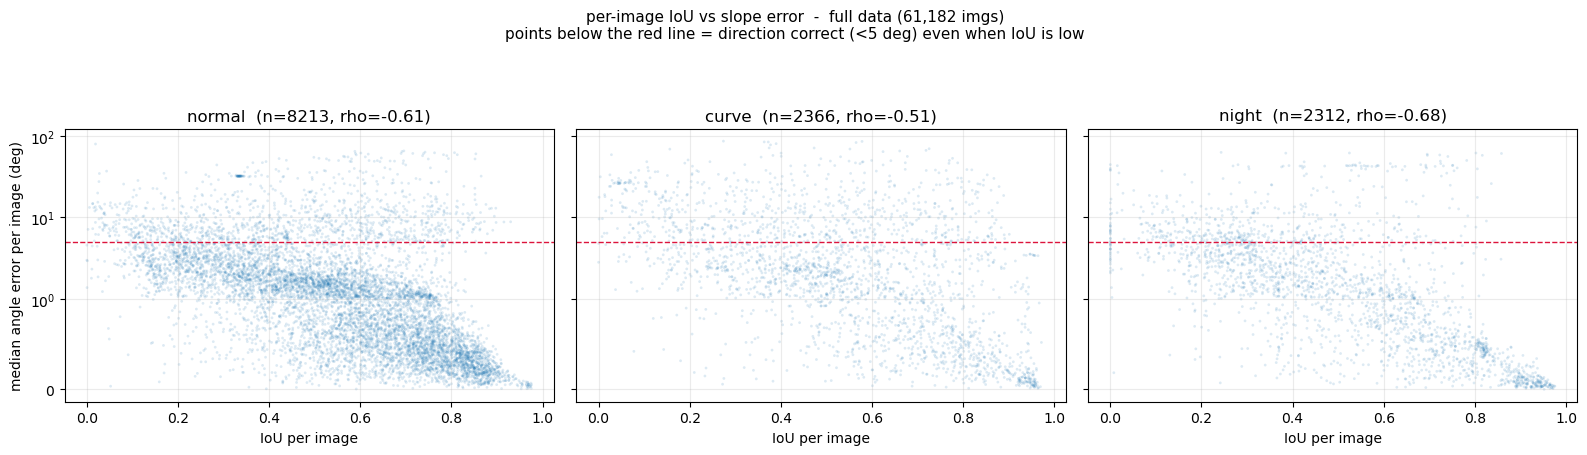

In [7]:
# หมายเหตุ: matplotlib บนเครื่องนี้ไม่มีฟอนต์ไทย (มีแต่ DejaVu/Liberation)
# ข้อความ *บนรูป* จึงเป็นภาษาอังกฤษ ไม่งั้นจะกลายเป็นสี่เหลี่ยมทั้งหมด
# กราฟกระจาย: IoU ต่อภาพ vs มุมคลาดต่อภาพ
name0 = list(paired.keys())[0]
recs = [r for r in paired[name0] if not np.isnan(r["slope_err"])]
cats = ["normal", "curve", "night"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, sharey=True)
for ax, c in zip(axes, cats):
    sel = [r for r in recs if r["category"] == c]
    x = np.array([r["iou"] for r in sel]); y = np.array([r["slope_err"] for r in sel])
    ax.scatter(x, y, s=4, alpha=0.15, edgecolors="none")
    ax.set_yscale("symlog", linthresh=1.0)
    ax.axhline(5, ls="--", lw=1, color="crimson")
    ax.set_title(f"{c}  (n={len(sel)}, rho={spearmanr(x, y).statistic:.2f})")
    ax.set_xlabel("IoU per image")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("median angle error per image (deg)")
fig.suptitle(f"per-image IoU vs slope error  -  {FIG_NAME.get(name0, name0)}\n"
             "points below the red line = direction correct (<5 deg) even when IoU is low", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.savefig("results/comparison/metric_comparison_scatter.png", dpi=110)
print("📁 บันทึกกราฟไว้ที่: results/metric_comparison_scatter.png")
plt.show()

## 4. ภาพที่สอง metric ขัดกัน

- **IoU ต่ำ แต่มุมถูก** → โมเดลชี้ทิศถูก แค่วางแถบเหลื่อม ถ้าเอาไปคุมพวงมาลัยยังใช้ได้
- **IoU สูง แต่มุมผิด** → พื้นที่ทับกันเยอะแต่ทิศเพี้ยน อันตรายกว่าและ IoU มองไม่เห็น

📁 บันทึกภาพไว้ที่: results/metric_disagreement_gallery.png


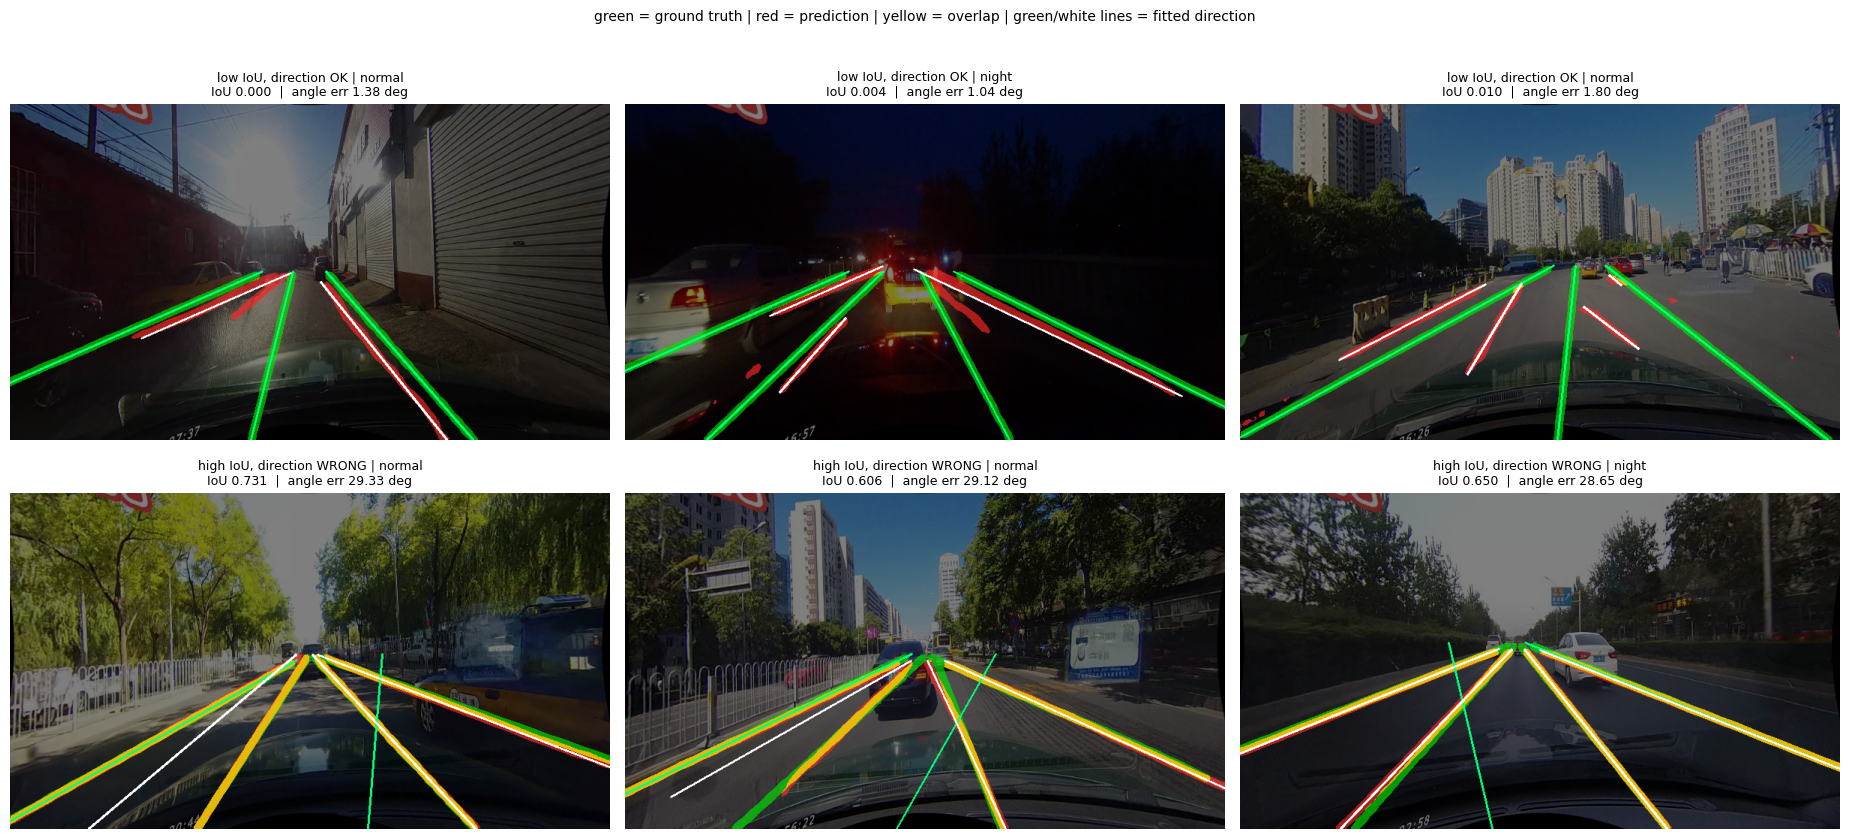

In [8]:
# หมายเหตุ: matplotlib บนเครื่องนี้ไม่มีฟอนต์ไทย (มีแต่ DejaVu/Liberation)
# ข้อความ *บนรูป* จึงเป็นภาษาอังกฤษ ไม่งั้นจะกลายเป็นสี่เหลี่ยมทั้งหมด
def gallery(model_name, n_each=3, seed=SEED):
    path, nz, enc = MODELS[model_name]
    recs = [(i, r) for i, r in enumerate(paired[model_name])
            if not np.isnan(r["slope_err"]) and r["n_matched"] >= 2]
    lo_iou_ok_ang = sorted([x for x in recs if x[1]["slope_err"] < 2.0],
                           key=lambda x: x[1]["iou"])[:n_each]
    hi_iou_bad_ang = sorted([x for x in recs if x[1]["iou"] > 0.55],
                            key=lambda x: -x[1]["slope_err"])[:n_each]
    picks = [(i, r, "low IoU, direction OK") for i, r in lo_iou_ok_ang] + \
            [(i, r, "high IoU, direction WRONG") for i, r in hi_iou_bad_ang]

    ds = LaneDatasetFromCSV(os.path.join(DATASET_ROOT, "test_list.csv"), IMG_DIR, MASK_DIR,
                            augment=False)
    model = load_model(path, enc)

    cols = n_each
    fig, axes = plt.subplots(2, cols, figsize=(6.2 * cols, 4.4 * 2))
    axes = np.atleast_1d(axes).ravel()
    for ax, (idx, rec, tagtxt) in zip(axes, picks):
        image_t, mask_t = ds[idx]
        with torch.inference_mode():
            x = image_t.unsqueeze(0).to(DEVICE)
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == "cuda")):
                logit = model(prep(x, nz))
            prob = torch.sigmoid(logit.float())[0, 0].cpu().numpy()
        # ต้อง ascontiguousarray: permute ของ torch ให้ array ที่ไม่ C-contiguous cv2 จะไม่รับ
        rgb = np.ascontiguousarray((image_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
        gt = mask_t[0].numpy() > 0.5
        pd = prob > THRESHOLD
        vis = (rgb * 0.5).astype(np.uint8)
        vis[gt] = (0.35 * vis[gt] + 0.65 * np.array([0, 230, 0])).astype(np.uint8)
        vis[pd] = (0.35 * vis[pd] + 0.65 * np.array([255, 40, 40])).astype(np.uint8)
        vis[gt & pd] = (0.3 * vis[gt & pd] + 0.7 * np.array([255, 230, 0])).astype(np.uint8)
        res = slope_metrics_for_pair(gt, pd)
        for d in res["gt_lanes"]:
            y0, y1 = int(d["y_top"]), int(d["y_bot"])
            cv2.line(vis, (int(d["a"]*y0+d["b"]), y0), (int(d["a"]*y1+d["b"]), y1), (0, 255, 120), 2)
        for d in res["pred_lanes"]:
            y0, y1 = int(d["y_top"]), int(d["y_bot"])
            cv2.line(vis, (int(d["a"]*y0+d["b"]), y0), (int(d["a"]*y1+d["b"]), y1), (255, 255, 255), 2)
        ax.imshow(vis); ax.axis("off")
        ax.set_title(f"{tagtxt} | {rec['category']}\nIoU {rec['iou']:.3f}  |  "
                     f"angle err {rec['slope_err']:.2f} deg", fontsize=9)
    for ax in axes[len(picks):]:
        ax.axis("off")
    fig.suptitle("green = ground truth | red = prediction | yellow = overlap | green/white lines = fitted direction",
                 fontsize=10)
    plt.tight_layout(rect=(0, 0, 1, 0.955), h_pad=2.5)
    plt.savefig("results/comparison/metric_disagreement_gallery.png", dpi=110)
    print("📁 บันทึกภาพไว้ที่: results/metric_disagreement_gallery.png")
    plt.show()


gallery(list(paired.keys())[0])

In [9]:
# สรุปจากตัวเลขที่วัดได้ในไฟล์นี้ — ทุกข้อความคำนวณจากข้อมูล ไม่ได้เขียนดักไว้ล่วงหน้า
name0 = list(paired.keys())[0]


def row_of(scope, model=None):
    return [r for r in cat_rows if r["model"] == (model or name0) and r["scope"] == scope][0]


def perturb_of(name):
    return [r for r in perturb_rows if r["perturbation"] == name][0]


allr, nrow, crow, nightrow = row_of("ทั้งหมด"), row_of("normal"), row_of("curve"), row_of("night")
shift, rot, dropped = perturb_of("เลื่อนขวา 10px"), perturb_of("หมุนเลน 5°"), perturb_of("ลบเลนทิ้ง 1 เส้น")

print("=" * 74)
print("สรุป: metric ตัวไหนเห็นอะไร (ตัวเลขทั้งหมดมาจากไฟล์นี้)")
print("=" * 74)

print(f"""
1) IoU แยกไม่ออกว่า "ผิดแบบไหน"
   เลื่อนเส้น 10px -> IoU {shift['iou']:.3f} | มุมคลาด {shift['slope_median']:.2f}°   ทิศถูกสนิท ไม่อันตราย
   หมุนเลน 5°      -> IoU {rot['iou']:.3f} | มุมคลาด {rot['slope_median']:.2f}°   ทิศเพี้ยนจริง อันตราย

   IoU ตกพอกันทั้งคู่ ถ้าดูแต่ IoU จะสรุปว่าแย่เท่ากัน ทั้งที่ความหมายคนละเรื่อง
   (ข้อควรระวัง: IoU ไม่ได้ "ตาบอด" ต่อการหมุน มันตกด้วย แต่มันแยกไม่ออกว่าตกเพราะอะไร)""")

print(f"\n2) แยกตามรูปแบบถนน (โมเดล: {name0})\n")
print(f"   {'ถนน':10s} {'IoU':>7s} {'มุมคลาด':>10s} {'recall':>8s} {'เฉลย fit ไม่ลง':>16s}")
print("   " + "-" * 56)
for r in (nrow, crow, nightrow):
    print(f"   {r['scope']:10s} {r['iou']:7.3f} {r['slope_median_pooled']:9.2f}° "
          f"{r['lane_recall']:8.3f} {r['badfit_frac']*100:15.1f}%")

iou_gap = abs(crow["iou"] - nrow["iou"]) / nrow["iou"] * 100
ang_ratio = crow["slope_median_pooled"] / nrow["slope_median_pooled"]
badfit_similar = crow["badfit_frac"] <= nrow["badfit_frac"] * 1.15

print(f"""
   ทางโค้งเทียบทางตรง: IoU ต่างกันแค่ {iou_gap:.1f}% แต่มุมคลาดต่างกัน {ang_ratio:.1f} เท่า
   ({nrow['slope_median_pooled']:.2f}° -> {crow['slope_median_pooled']:.2f}°)""")

if badfit_similar:
    print(f"""   และสัดส่วนเส้น "เฉลย" ที่ fit เส้นตรงไม่ลงพอๆ กัน
   ({nrow['badfit_frac']*100:.1f}% vs {crow['badfit_frac']*100:.1f}%)
   จึงอธิบายด้วย "ทางโค้ง fit เส้นตรงไม่ได้" ไม่ได้ — เป็นเพราะโมเดลทำนายทิศบนทางโค้งแย่กว่าจริงๆ

   >>> ข้อสรุปที่สำคัญที่สุดของไฟล์นี้
       บนทางโค้ง IoU บอกว่า "พอๆ กับทางตรง" (ต่างกัน {iou_gap:.1f}%)
       แต่ความชันบอกว่าแย่กว่า {ang_ratio:.1f} เท่า
       ถ้าวัดด้วย IoU อย่างเดียว จะมองไม่เห็นเลยว่าทางโค้งคือจุดอ่อนของโมเดล""")
    # ตัวเลข "กี่เท่า" ขึ้นกับว่าใช้ median แบบไหน ทิศทางข้อสรุปเหมือนกันแต่เลขไม่เท่ากัน
    _r_img = crow["slope_median_per_image"] / nrow["slope_median_per_image"]
    print(f"       (ถ้าคิด median แบบต่อภาพแทน จะได้ {_r_img:.1f} เท่า — "
          f"ข้อสรุปเดิม ตัวเลขต่างเพราะคนละวิธีเฉลี่ย)")
else:
    print(f"""   แต่ทางโค้งมีเส้นเฉลยที่ fit เส้นตรงไม่ลงมากกว่าด้วย
   ({nrow['badfit_frac']*100:.1f}% -> {crow['badfit_frac']*100:.1f}%)
   ดังนั้นมุมคลาดที่สูงขึ้นส่วนหนึ่งมาจากข้อจำกัดของ metric เอง ไม่ใช่โมเดลล้วนๆ""")

print(f"""
3) ควรใช้ตัวไหน — ใช้ทั้งคู่ ไม่ใช่ตัวเดียว เพราะจุดบอดคนละที่
     ความชัน      -> "ทิศถูกไหม"      ทนต่อการเลื่อนตำแหน่ง เหมาะกับงานคุมทิศทาง
     IoU          -> "ทับกันแค่ไหน"   รวมทุกความผิดพลาดเป็นเลขเดียว แยกสาเหตุไม่ได้
     lane_recall  -> "ตรวจเจอครบไหม"  ซึ่งอีกสองตัวไม่ได้บอก
                     (ลบเลนทิ้ง 1 เส้น: มุมคลาดยัง {dropped['slope_median']:.2f}° แต่ recall เหลือ {dropped['lane_recall']:.3f})

   ค่าปัจจุบันของโมเดล {name0}:
     IoU {allr['iou']:.3f} | มุมคลาด {allr['slope_median_pooled']:.2f}° | lane_recall {allr['lane_recall']:.3f}
""")

สรุป: metric ตัวไหนเห็นอะไร (ตัวเลขทั้งหมดมาจากไฟล์นี้)

1) IoU แยกไม่ออกว่า "ผิดแบบไหน"
   เลื่อนเส้น 10px -> IoU 0.319 | มุมคลาด 0.00°   ทิศถูกสนิท ไม่อันตราย
   หมุนเลน 5°      -> IoU 0.252 | มุมคลาด 4.96°   ทิศเพี้ยนจริง อันตราย

   IoU ตกพอกันทั้งคู่ ถ้าดูแต่ IoU จะสรุปว่าแย่เท่ากัน ทั้งที่ความหมายคนละเรื่อง
   (ข้อควรระวัง: IoU ไม่ได้ "ตาบอด" ต่อการหมุน มันตกด้วย แต่มันแยกไม่ออกว่าตกเพราะอะไร)

2) แยกตามรูปแบบถนน (โมเดล: ข้อมูลเต็ม 61,182)

   ถนน            IoU    มุมคลาด   recall   เฉลย fit ไม่ลง
   --------------------------------------------------------
   normal       0.550      0.89°    0.916             9.7%
   curve        0.544      1.25°    0.872             8.4%
   night        0.477      1.08°    0.865            10.0%

   ทางโค้งเทียบทางตรง: IoU ต่างกันแค่ 1.2% แต่มุมคลาดต่างกัน 1.4 เท่า
   (0.89° -> 1.25°)
   และสัดส่วนเส้น "เฉลย" ที่ fit เส้นตรงไม่ลงพอๆ กัน
   (9.7% vs 8.4%)
   จึงอธิบายด้วย "ทางโค้ง fit เส้นตรงไม่ได้" ไม่ได้ — เป็นเพราะโมเดลทำนายทิศบนทางโค้งแย่กว่

## คำตอบตรงคำถาม: ถนนแบบไหนควรใช้ metric ตัวไหน

ดูจากตารางด้านบน โดยเทียบ **ส่วนต่างจากทางตรง (normal)** ซึ่งเป็นฐาน

| | IoU เปลี่ยน | มุมคลาดเปลี่ยน | recall เปลี่ยน | สองตัวเห็นตรงกันไหม |
| --- | --- | --- | --- | --- |
| **ทางโค้ง** (โมเดลข้อมูลเต็ม) | −1.2% | **+40.8%** | −4.9% | **ไม่ตรงกัน** |
| ทางโค้ง (subset 2,000) | −4.3% | **+58.9%** | −2.8% | **ไม่ตรงกัน** |
| **กลางคืน** (โมเดลข้อมูลเต็ม) | −13.2% | +22.0% | −5.6% | ตรงกัน |
| กลางคืน (subset 2,000) | −14.1% | +7.4% | −7.0% | ตรงกัน |

**สองตัวให้คำตอบต่างกันแค่กรณีเดียวคือทางโค้ง** และจุดนั้นความชันคือตัวที่เวิร์กกว่า

- **ทางโค้ง → ใช้ความชัน** IoU แทบไม่ขยับ (−1.2%) จะสรุปว่า "ทางโค้งพอๆ กับทางตรง"
  แต่ความชันบอกว่าแย่ลง 40–59% ซ้ำเหมือนกันทั้งสองโมเดล ถ้าวัดด้วย IoU อย่างเดียวจะมองไม่เห็น
  จุดอ่อนนี้เลย
- **กลางคืน → IoU (คู่กับ recall) พอแล้ว** ที่นี่ IoU ตกแรงกว่ามุมคลาด (−13% เทียบ +22%,
  และในโมเดล subset คือ −14% เทียบ +7.4%) เพราะความผิดพลาดกลางคืนคือ **มองไม่เห็นเส้น**
  ไม่ใช่ **เล็งผิดทิศ** — recall ก็ตกด้วย ซึ่ง IoU/recall รายงานอยู่แล้ว
  ตรงนี้ความชันกลับเป็นตัวที่ไวน้อยกว่า
- **ทางตรง → ใช้ตัวไหนก็ได้** สองตัวเห็นตรงกัน และเป็นหมวดที่โมเดลทำได้ดีที่สุดอยู่แล้ว

สรุปให้สั้นที่สุด: **ไม่มีตัวไหนชนะขาด** ความชันเห็นสิ่งที่ IoU มองไม่เห็นบนทางโค้ง
ส่วน IoU+recall เห็นสิ่งที่ความชันมองไม่เห็นตอนกลางคืน จึงควรรายงานคู่กันเสมอ
